In [10]:
"""
AAA_t_test2_multi_freq

Test the focused t-interpolation helper functions for several Matsubara frequencies.
Both SCE and WCE orders are set to 6.
"""

'\nAAA_t_test2_multi_freq\n\nTest the focused t-interpolation helper functions for several Matsubara frequencies.\nBoth SCE and WCE orders are set to 6.\n'

In [11]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt

from t_interpolation_workflow import (
    compute_exact_t,
    build_t_app_G_app,
)
from _bary_rational import AAA_holo_interp_v2

In [12]:
beta = 10.0
Ns = 2
Nw = 4 * int(beta)
Mat_fre = (2 * np.linspace(0, Nw - 1, Nw) + 1) * np.pi / beta
wn = np.append(-np.flip(Mat_fre), Mat_fre)

U = 4.0
T = 20.0
Nt = 1001
t_values_ED = np.linspace(0, T, Nt)

sce_order = 4
wce_order = 4
epsilon = 1e-3

In [13]:
G_exact = compute_exact_t(t_values_ED, wn, U, beta)
print(G_exact.shape)

(1001, 80, 2, 2)


In [14]:
wn_id = [Nw-1, Nw-2, Nw-3, Nw-4, Nw-5]
print("Selected Matsubara indices:", wn_id)
print("Selected omegas:", wn[wn_id])

t_app_by_n = {}
G_app_by_n = {}
missing_t_domain_by_n = {}

for n in wn_id:
    t_app, G_app, missing_t_domain = build_t_app_G_app(
        sce_order=sce_order,
        wce_order=wce_order,
        baseline_G=G_exact[:, n],
        t_values=t_values_ED,
        epsilon=epsilon,
        wn=wn[n],
        U=U,
        beta=beta,
    )
    t_app_by_n[n] = t_app
    G_app_by_n[n] = G_app
    missing_t_domain_by_n[n] = missing_t_domain
    print(f"n={n}, omega={wn[n]:.6g}, t_app shape={t_app.shape}, G_app shape={G_app.shape}, t range=({t_app.min():.4g}, {t_app.max():.4g})")

Selected Matsubara indices: [39, 38, 37, 36, 35]
Selected omegas: [-0.31415927 -0.9424778  -1.57079633 -2.19911486 -2.82743339]
SCE t domain: (0.0, 0.2) WCE t domain: (2.96, 20.0)
Missing t domain: (0.2, 2.96)
n=39, omega=-0.314159, t_app shape=(2002,), G_app shape=(2002, 2, 2), t range=(0, 20)
SCE t domain: (0.0, 0.22) WCE t domain: (2.8000000000000003, 20.0)
Missing t domain: (0.22, 2.8000000000000003)
n=38, omega=-0.942478, t_app shape=(2002,), G_app shape=(2002, 2, 2), t range=(0, 20)
SCE t domain: (0.0, 0.24) WCE t domain: (2.72, 20.0)
Missing t domain: (0.24, 2.72)
n=37, omega=-1.5708, t_app shape=(2002,), G_app shape=(2002, 2, 2), t range=(0, 20)
SCE t domain: (0.0, 0.28) WCE t domain: (2.44, 20.0)
Missing t domain: (0.28, 2.44)
n=36, omega=-2.19911, t_app shape=(2002,), G_app shape=(2002, 2, 2), t range=(0, 20)
SCE t domain: (0.0, 0.32) WCE t domain: (2.0, 20.0)
Missing t domain: (0.32, 2.0)
n=35, omega=-2.82743, t_app shape=(2002,), G_app shape=(2002, 2, 2), t range=(0, 20)


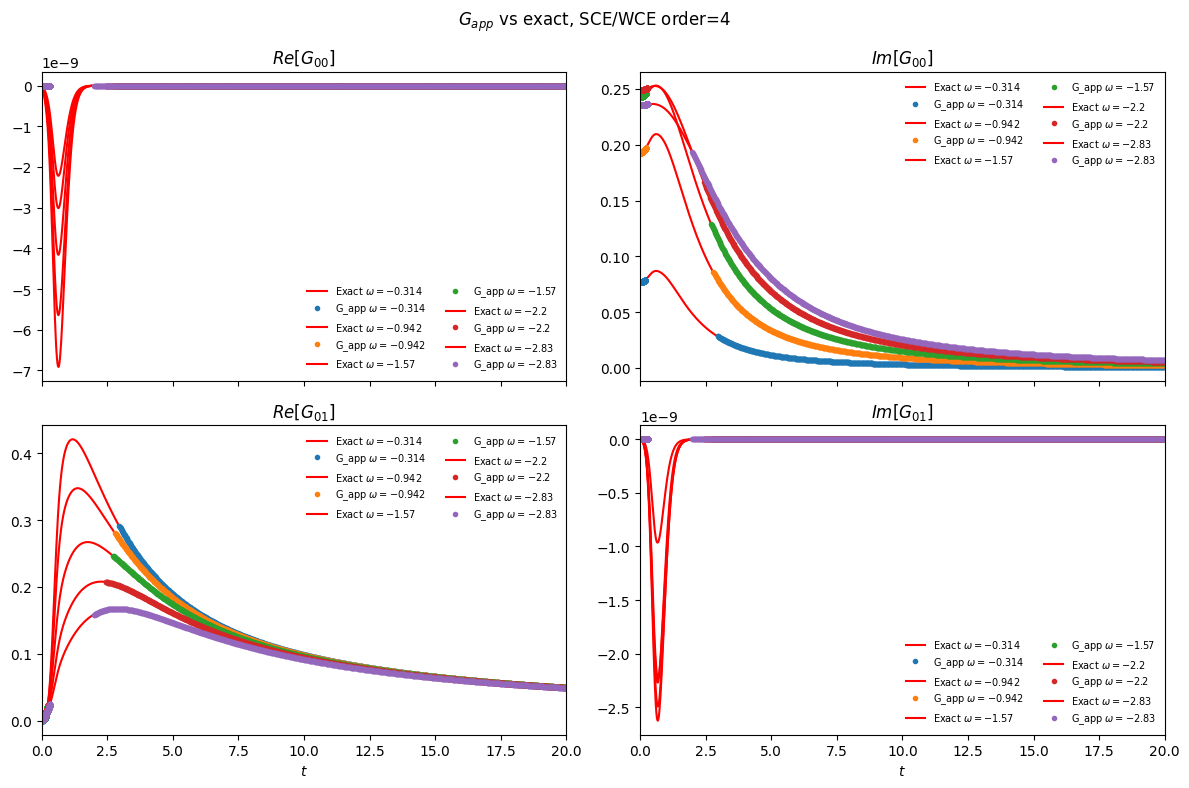

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

for n in wn_id:
    t_app = t_app_by_n[n]
    G_app = G_app_by_n[n]

    axes[0, 0].plot(t_values_ED, G_exact[:, n, 0, 0].real, 'r-', label=rf"Exact $\omega={wn[n]:.3g}$")
    axes[0, 0].plot(t_app, G_app[:, 0, 0].real, ".", label=rf"G_app $\omega={wn[n]:.3g}$")

    axes[0, 1].plot(t_values_ED, G_exact[:, n, 0, 0].imag, 'r-', label=rf"Exact $\omega={wn[n]:.3g}$")
    axes[0, 1].plot(t_app, G_app[:, 0, 0].imag, ".", label=rf"G_app $\omega={wn[n]:.3g}$")

    axes[1, 0].plot(t_values_ED, G_exact[:, n, 0, 1].real, 'r-', label=rf"Exact $\omega={wn[n]:.3g}$")
    axes[1, 0].plot(t_app, G_app[:, 0, 1].real, ".", label=rf"G_app $\omega={wn[n]:.3g}$")

    axes[1, 1].plot(t_values_ED, G_exact[:, n, 0, 1].imag, 'r-', label=rf"Exact $\omega={wn[n]:.3g}$")
    axes[1, 1].plot(t_app, G_app[:, 0, 1].imag, ".", label=rf"G_app $\omega={wn[n]:.3g}$")

axes[0, 0].set_title(r"$Re[G_{00}]$")
axes[0, 1].set_title(r"$Im[G_{00}]$")
axes[1, 0].set_title(r"$Re[G_{01}]$")
axes[1, 1].set_title(r"$Im[G_{01}]$")

for ax in axes[1, :]:
    ax.set_xlabel(r"$t$")
for ax in axes.ravel():
    ax.set_xlim([0, T])
    ax.legend(frameon=False, fontsize=7, ncol=2)

fig.suptitle(r"$G_{app}$ vs exact, SCE/WCE order=%d" % sce_order)
fig.tight_layout()
plt.show()

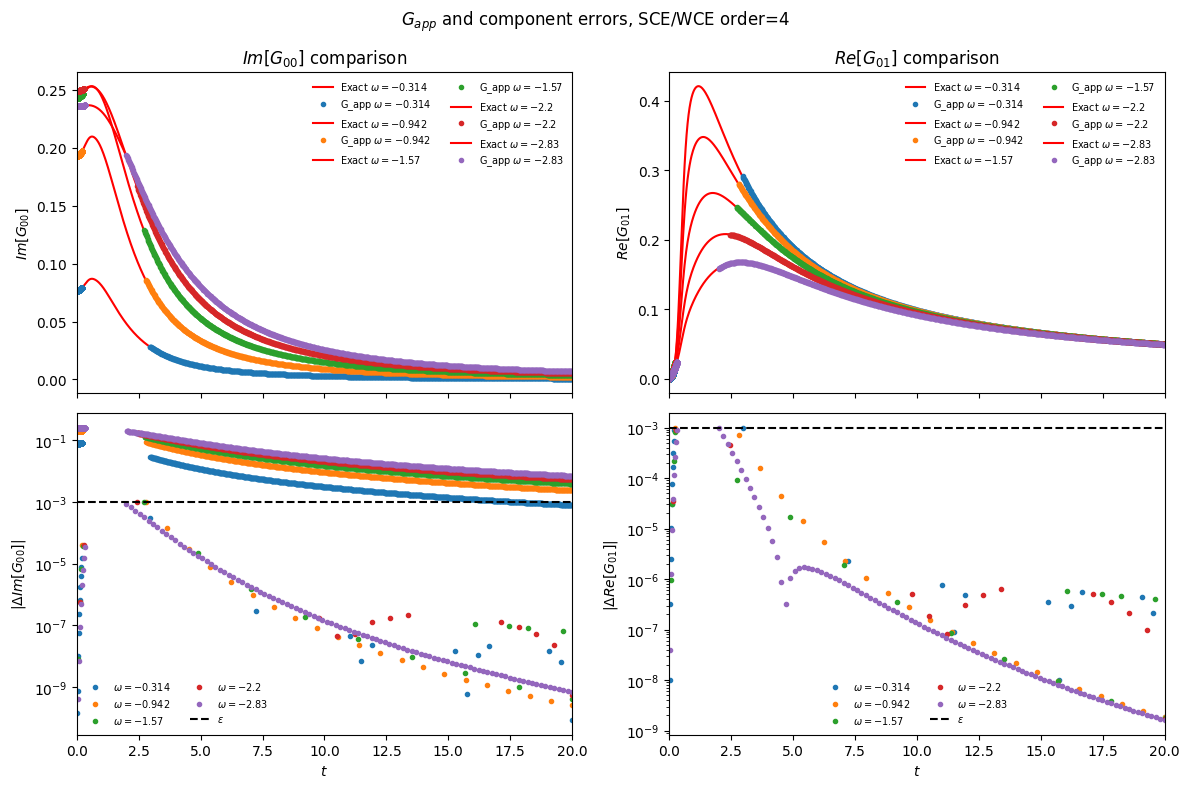

2002


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex="col")

for n in wn_id:
    t_app = t_app_by_n[n]
    G_app = G_app_by_n[n]

    exact_at_app = np.zeros_like(G_app)
    for k, t in enumerate(t_app):
        idx = np.where(np.isclose(t_values_ED, t))[0]
        if idx.size:
            exact_at_app[k] = G_exact[idx[0], n]
        else:
            exact_at_app[k] = np.nan

    G00_im_error = np.abs(G_app[:, 0, 0].imag- exact_at_app[:, 0, 0].imag)
    G01_re_error = np.abs(G_app[:, 0, 1] - exact_at_app[:, 0, 1])

    axes[0, 0].plot(t_values_ED, G_exact[:, n, 0, 0].imag, 'r-', label=rf"Exact $\omega={wn[n]:.3g}$")
    axes[0, 0].plot(t_app, G_app[:, 0, 0].imag, ".", label=rf"G_app $\omega={wn[n]:.3g}$")
    axes[1, 0].semilogy(t_app, G00_im_error, ".", label=rf"$\omega={wn[n]:.3g}$")

    axes[0, 1].plot(t_values_ED, G_exact[:, n, 0, 1].real, 'r-', label=rf"Exact $\omega={wn[n]:.3g}$")
    axes[0, 1].plot(t_app, G_app[:, 0, 1].real, ".", label=rf"G_app $\omega={wn[n]:.3g}$")
    axes[1, 1].semilogy(t_app, G01_re_error, ".", label=rf"$\omega={wn[n]:.3g}$")

axes[0, 0].set_ylabel(r"$Im[G_{00}]$")
axes[0, 0].set_title(r"$Im[G_{00}]$ comparison")
axes[1, 0].axhline(epsilon, color="k", linestyle="--", label=r"$\epsilon$")
axes[1, 0].set_xlabel(r"$t$")
axes[1, 0].set_ylabel(r"$|\Delta Im[G_{00}]|$")

axes[0, 1].set_ylabel(r"$Re[G_{01}]$")
axes[0, 1].set_title(r"$Re[G_{01}]$ comparison")
axes[1, 1].axhline(epsilon, color="k", linestyle="--", label=r"$\epsilon$")
axes[1, 1].set_xlabel(r"$t$")
axes[1, 1].set_ylabel(r"$|\Delta Re[G_{01}]|$")

for ax in axes.ravel():
    ax.set_xlim([0, T])
    ax.legend(frameon=False, fontsize=7, ncol=2)

fig.suptitle(r"$G_{app}$ and component errors, SCE/WCE order=%d" % sce_order)
fig.tight_layout()
plt.show()

print(t_app.size)

In [17]:
### Multi-frequency G_app construction and AAA interpolation test
wn_id = [Nw-1, Nw-2, Nw-3, Nw-4, Nw-5]
max_terms = 20
max_trials = 1000
perturbation_magnitude = epsilon

G00_interp = np.zeros((t_values_ED.size, len(wn_id)), dtype=complex)
G01_interp = np.zeros((t_values_ED.size, len(wn_id)), dtype=complex)
t_app_by_n = {}
G_app_by_n = {}
missing_t_domain_by_n = {}
pole_real_window = (4/5, 4/5)
for col, n in enumerate(wn_id):
    print("n=", n, "omega=", wn[n])
    t_app, G_app, missing_t_domain = build_t_app_G_app(
        sce_order=sce_order,
        wce_order=wce_order,
        baseline_G=G_exact[:, n],
        t_values=t_values_ED,
        epsilon=epsilon,
        wn=wn[n],
        U=U,
        beta=beta,
    )
    t_app_by_n[n] = t_app
    G_app_by_n[n] = G_app
    missing_t_domain_by_n[n] = missing_t_domain

    # pole_real_window = missing_t_domain

    r00 = AAA_holo_interp_v2(
        t_app, G_app[:, 0, 0].imag, rtol=epsilon, max_terms=max_terms,
        pole_real_window=pole_real_window, max_trials=max_trials,
        perturbation_magnitude=perturbation_magnitude,
    )
    r01 = AAA_holo_interp_v2(
        t_app, G_app[:, 0, 1].real, rtol=epsilon, max_terms=max_terms,
        pole_real_window=pole_real_window, max_trials=max_trials,
        perturbation_magnitude=perturbation_magnitude,
    )
    G00_interp[:, col] = 1j*r00(t_values_ED)
    G01_interp[:, col] = r01(t_values_ED)

n= 39 omega= -0.3141592653589793
SCE t domain: (0.0, 0.2) WCE t domain: (2.96, 20.0)
Missing t domain: (0.2, 2.96)
n= 38 omega= -0.9424777960769379
SCE t domain: (0.0, 0.22) WCE t domain: (2.8000000000000003, 20.0)
Missing t domain: (0.22, 2.8000000000000003)
n= 37 omega= -1.5707963267948966
SCE t domain: (0.0, 0.24) WCE t domain: (2.72, 20.0)
Missing t domain: (0.24, 2.72)
n= 36 omega= -2.199114857512855
SCE t domain: (0.0, 0.28) WCE t domain: (2.44, 20.0)
Missing t domain: (0.28, 2.44)
n= 35 omega= -2.827433388230814
SCE t domain: (0.0, 0.32) WCE t domain: (2.0, 20.0)
Missing t domain: (0.32, 2.0)


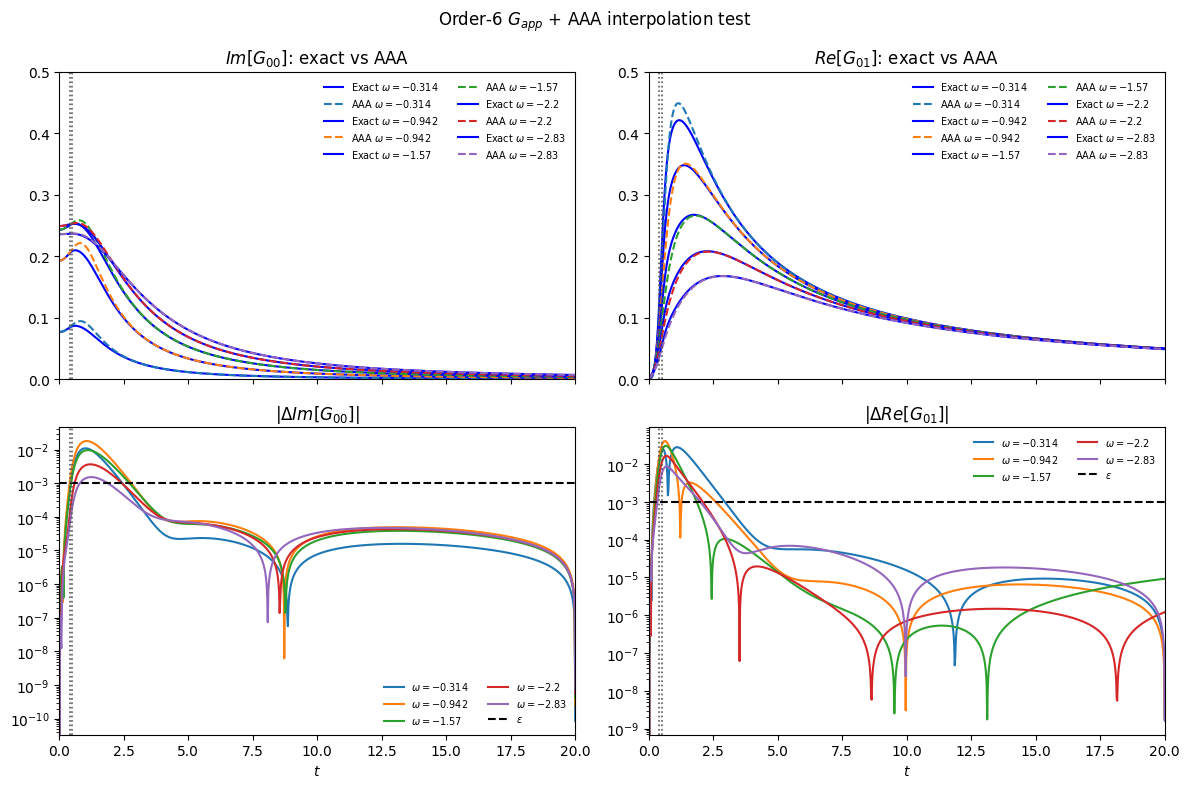

In [18]:
pole_real_window = (2/5, 1/2)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

for col, n in enumerate(wn_id):
    axes[0, 0].plot(t_values_ED, G_exact[:, n, 0, 0].imag, "b", label=rf"Exact $\omega={wn[n]:.3g}$")
    axes[0, 0].plot(t_values_ED, G00_interp[:, col].imag, "--", label=rf"AAA $\omega={wn[n]:.3g}$")

    axes[0, 1].plot(t_values_ED, G_exact[:, n, 0, 1].real, "b", label=rf"Exact $\omega={wn[n]:.3g}$")
    axes[0, 1].plot(t_values_ED, G01_interp[:, col].real, "--", label=rf"AAA $\omega={wn[n]:.3g}$")

    axes[1, 0].semilogy(t_values_ED, np.abs(G_exact[:, n, 0, 0].imag - G00_interp[:, col].imag), label=rf"$\omega={wn[n]:.3g}$")
    axes[1, 1].semilogy(t_values_ED, np.abs(G_exact[:, n, 0, 1].real - G01_interp[:, col].real), label=rf"$\omega={wn[n]:.3g}$")

axes[0, 0].set_title(r"$Im[G_{00}]$: exact vs AAA")
axes[0, 1].set_title(r"$Re[G_{01}]$: exact vs AAA")
axes[1, 0].set_title(r"$|\Delta Im[G_{00}]|$")
axes[1, 1].set_title(r"$|\Delta Re[G_{01}]|$")
axes[1, 0].axhline(epsilon, color="k", linestyle="--", label=r"$\epsilon$")
axes[1, 1].axhline(epsilon, color="k", linestyle="--", label=r"$\epsilon$")

for ax in axes[1, :]:
    ax.set_xlabel(r"$t$")
for ax in axes.ravel():
    ax.set_xlim([0, T])
    ax.axvline(pole_real_window[0], color="0.35", linestyle=":", linewidth=1.2)
    ax.axvline(pole_real_window[1], color="0.35", linestyle=":", linewidth=1.2)
    axes[0,0].set_ylim([0, 0.5])
    axes[0,1].set_ylim([0, 0.5])
    # axes[1,0].set_xlim([2/5, 4/5])
    # axes[1,1].set_xlim([2/5, 4/5])
    ax.legend(frameon=False, fontsize=7, ncol=2)

fig.suptitle(r"Order-6 $G_{app}$ + AAA interpolation test")
fig.tight_layout()
plt.show()